
# Category Embedding V2 – Frequency-Based User Profiles

Order-invariant embeddings built from category frequencies so that clustering reflects what users buy, not when. This notebook connects to the DuckDB warehouse, aggregates per-user category usage, projects the high-dimensional frequency vectors, and surfaces dominant category preferences per cluster.



## Pipeline Overview
1. **Extract** user/category interactions from DuckDB with optional event-type weighting (purchases can count more than views).
2. **Aggregate & Normalize** frequencies per user while expanding hierarchical category tokens (level 1 → level N).
3. **Embed** users as dense vectors using Truncated SVD on the frequency matrix (orderless by construction).
4. **Cluster & Interpret** users via KMeans, providing per-cluster top categories plus 2D visual diagnostics.

> ⚠️ All steps are controlled via the configuration cell below—update paths, weights, or model hyperparameters before running the pipeline end-to-end.


In [1]:

# Core imports
import duckdb
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")


### Connexion à la DB / Import des Data


In [2]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [3]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 4 tables in the database:

1. all_events
2. loaded_files
3. user_events
4. user_segments_kmeans


In [4]:

# Configuration — edit to match your environment / scenario
PROJECT_ROOT = Path('/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing')
DB_PATH = PROJECT_ROOT / 'amazing.duckdb'
SOURCE_TABLE = 'all_events'  # alternatively `user_events` if already aggregated
EVENT_TYPES = ['view', 'cart', 'purchase']
EVENT_TYPE_WEIGHTS: Dict[str, float] = {
    'view': 1.0,
    'cart': 1.5,
    'purchase': 2.0,
}
USER_SAMPLE_LIMIT = None  # set to an int (e.g. 25_000) during exploration to keep runtime manageable
MAX_CATEGORY_DEPTH = 3     # how deep the hierarchical tokens should go (1=top-level only)
N_COMPONENTS = 25          # TruncatedSVD components for dense embeddings
N_CLUSTERS = 6             # KMeans clusters; tune after inspecting silhouette score
RANDOM_STATE = 42

assert DB_PATH.exists(), f"DuckDB database not found at {DB_PATH}"
print(f"Using database: {DB_PATH}")


Using database: /home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/amazing.duckdb


In [5]:

# Connect to DuckDB and list available tables for quick sanity-checks
con = duckdb.connect(str(DB_PATH))
all_events_df = con.execute(f"SELECT * FROM all_events LIMIT 10000").df()


In [6]:

# Aggregate weighted category counts per user from imported DataFrame (order-invariant)
if not EVENT_TYPES:
    raise ValueError("EVENT_TYPES cannot be empty – specify at least one event type to include.")

# Filter and prepare data from imported DataFrame
filtered_df = all_events_df[
    (all_events_df['category_code'].notna()) & 
    (all_events_df['event_type'].isin(EVENT_TYPES))
].copy()

# Convert category codes to lowercase and add weights
filtered_df['category_code'] = filtered_df['category_code'].str.lower()
filtered_df['weight'] = filtered_df['event_type'].map(EVENT_TYPE_WEIGHTS).fillna(1.0)

# Aggregate by user and category
user_category_counts = filtered_df.groupby(['user_id', 'category_code']).agg({
    'weight': 'sum'
}).reset_index()
user_category_counts.columns = ['user_id', 'category_code', 'weighted_count']

print(f"Loaded {len(user_category_counts):,} user/category pairs from imported DataFrame")

if USER_SAMPLE_LIMIT is not None:
    unique_users = user_category_counts['user_id'].drop_duplicates()
    sample_n = min(USER_SAMPLE_LIMIT, unique_users.shape[0])
    sampled_users = unique_users.sample(sample_n, random_state=RANDOM_STATE)
    user_category_counts = user_category_counts[user_category_counts['user_id'].isin(sampled_users)]
    print(f"Down-sampled to {sample_n:,} users for prototyping")

user_category_counts.head()


Loaded 2,596 user/category pairs from imported DataFrame


,user_id,category_code,weighted_count
0,120701478,construction.tools.light,1.0
1,416533463,accessories.bag,1.0
2,416533463,apparel.jumper,2.0
3,475967908,construction.tools.light,1.0
4,479953492,apparel.shoes.slipons,2.0


In [7]:

# Expand hierarchical category tokens and build an orderless frequency matrix
if user_category_counts.empty:
    raise ValueError("No category interactions after filtering – adjust EVENT_TYPES or source table.")


def expand_category_tokens(category: str, max_depth: int) -> List[str]:
    parts = category.split('.')
    depth = min(len(parts), max_depth)
    return ['.'.join(parts[:i + 1]) for i in range(depth)] if depth else []

records = []
for row in user_category_counts.itertuples(index=False):
    tokens = expand_category_tokens(row.category_code, MAX_CATEGORY_DEPTH)
    if not tokens:
        continue
    for token in tokens:
        records.append((row.user_id, token, row.weighted_count))

expanded_df = pd.DataFrame(records, columns=['user_id', 'category_token', 'weighted_count'])

user_totals = expanded_df.groupby('user_id')['weighted_count'].sum().rename('user_total')
expanded_df = expanded_df.join(user_totals, on='user_id')
expanded_df['frequency'] = expanded_df['weighted_count'] / expanded_df['user_total']

embedding_matrix = expanded_df.pivot_table(
    index='user_id',
    columns='category_token',
    values='frequency',
    fill_value=0.0
)

print(f"Embedding matrix shape: {embedding_matrix.shape[0]:,} users x {embedding_matrix.shape[1]:,} category tokens")
embedding_matrix.head()


Embedding matrix shape: 1,547 users x 153 category tokens


category_token,accessories,accessories.bag,accessories.umbrella,accessories.wallet,apparel,apparel.costume,apparel.dress,apparel.jeans,apparel.jumper,apparel.pajamas,...,medicine.tools.tonometer,sport,sport.bicycle,sport.diving,sport.ski,sport.snowboard,sport.tennis,sport.trainer,stationery,stationery.cartrige
user_id,,,,,,,,,,,,,,,,,,,,,
120701478,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
416533463,0.166667,0.166667,0.0,0.0,0.333333,0.0,0.0,0.0,0.333333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
475967908,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
479953492,0.000000,0.000000,0.0,0.0,0.333333,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
494293312,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:

# Inspect the most frequent categories globally to sanity-check distribution
category_profile = (
    expanded_df.groupby('category_token')['frequency']
    .mean()
    .sort_values(ascending=False)
)

print("Top 15 categories by mean normalized frequency across users:")
category_profile.head(15)


Top 15 categories by mean normalized frequency across users:


category_token
appliances.sewing_machine          0.408929
appliances.ironing_board           0.364583
apparel.scarf                      0.334844
furniture.universal                0.320000
furniture.universal.light          0.320000
kids.skates                        0.318724
sport.bicycle                      0.312633
appliances.personal.hair_cutter    0.312500
electronics.clocks                 0.302651
construction.tools.light           0.295272
appliances.kitchen.hood            0.284091
construction.tools                 0.283408
electronics.tablet                 0.282855
accessories.wallet                 0.281997
construction                       0.279308
Name: frequency, dtype: float64

In [9]:

# Dimensionality reduction (TruncatedSVD) for dense embeddings
if embedding_matrix.shape[1] < 2:
    raise ValueError("Not enough distinct category tokens to perform SVD. Consider increasing MAX_CATEGORY_DEPTH.")

effective_components = min(N_COMPONENTS, embedding_matrix.shape[1] - 1)
svd = TruncatedSVD(n_components=effective_components, random_state=RANDOM_STATE)
reduced_embeddings = svd.fit_transform(embedding_matrix)
explained_var = svd.explained_variance_ratio_.sum()
print(f"Explained variance by {effective_components} components: {explained_var:.2%}")
reduced_embeddings[:5]


Explained variance by 25 components: 85.61%


array([[ 5.76649863e-01, -1.00840947e-02, -1.44988749e-02,
        -7.72213185e-03, -2.26224497e-03, -8.04129345e-04,
        -2.28932420e-03,  1.77024488e-03, -1.34331229e-03,
         1.19375952e-03,  6.13969720e-04, -5.44451390e-04,
        -1.77667828e-03, -4.77280326e-03, -4.37754633e-03,
         5.42830111e-03,  1.71602332e-02, -3.72102092e-04,
         6.91150190e-04, -2.97540477e-03,  5.67349284e-03,
        -1.29417565e-04, -6.87225072e-04, -9.32796982e-05,
        -1.16573278e-03],
       [ 3.91673240e-03,  2.74099751e-01, -2.68318967e-02,
        -1.71502362e-02, -8.85854805e-03, -9.32963881e-04,
        -5.81612263e-04,  4.89836700e-03,  6.21685970e-03,
         7.12056424e-04, -2.08384799e-01,  1.66753250e-01,
        -1.52530051e-02,  6.48909698e-03, -1.49447984e-03,
        -1.00022202e-03,  6.90219226e-03, -2.23885511e-02,
        -1.99746282e-03,  3.46755240e-03,  4.56769569e-03,
        -1.12826060e-02, -3.16046339e-02, -1.69589827e-02,
        -1.04004815e-02],
    

In [10]:

# Cluster users in the reduced space and profile each cluster
if N_CLUSTERS < 2:
    raise ValueError("Use at least 2 clusters for KMeans.")

kmeans = KMeans(n_clusters=N_CLUSTERS, n_init='auto', random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(reduced_embeddings)
cluster_assignments = pd.DataFrame({
    'user_id': embedding_matrix.index,
    'cluster_id': cluster_labels,
})

try:
    silhouette = silhouette_score(reduced_embeddings, cluster_labels)
    print(f"Silhouette score: {silhouette:.3f}")
except Exception as exc:
    print(f"Silhouette score unavailable: {exc}")

cluster_profiles = (
    expanded_df.merge(cluster_assignments, on='user_id')
    .groupby(['cluster_id', 'category_token'])['frequency']
    .mean()
    .reset_index()
)

def top_categories_per_cluster(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    return (
        df.sort_values(['cluster_id', 'frequency'], ascending=[True, False])
          .groupby('cluster_id')
          .head(top_n)
          .reset_index(drop=True)
    )

cluster_top_categories = top_categories_per_cluster(cluster_profiles, top_n=10)
cluster_top_categories


Silhouette score: 0.392


,cluster_id,category_token,frequency
0,0,construction.tools.pump,0.291667
1,0,construction.components,0.266632
2,0,construction.components.faucet,0.266632
3,0,construction.tools.welding,0.257253
4,0,construction.tools.drill,0.252630
5,0,construction.tools.saw,0.231286
6,0,electronics.camera.photo,0.222222
7,0,construction,0.218702
8,0,construction.tools,0.211975
9,0,apparel.costume,0.200000


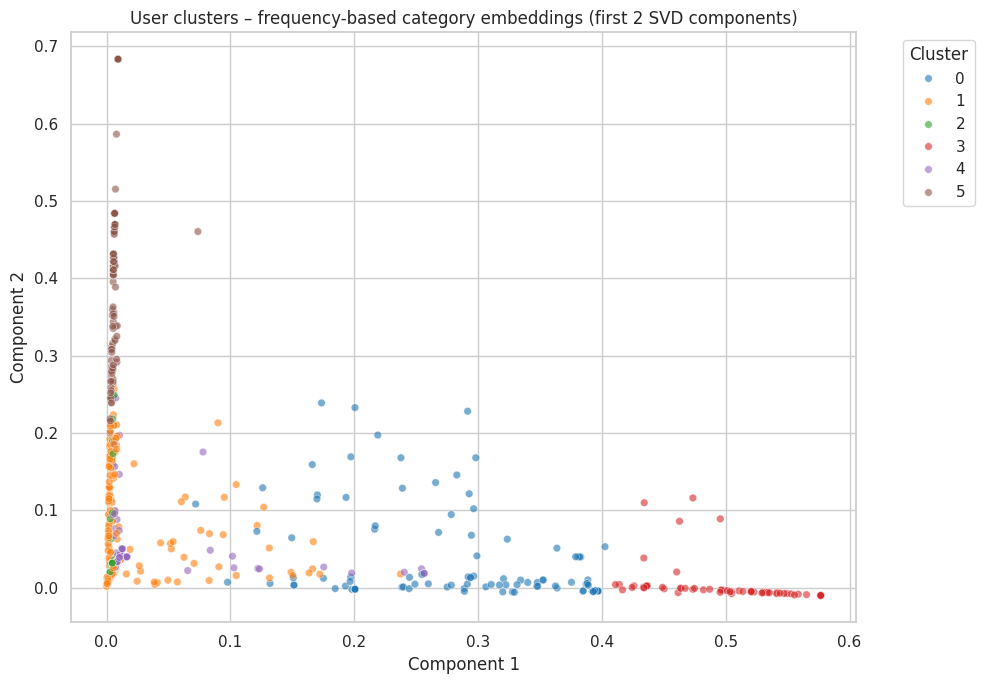

In [11]:

# 2D visualization using the first two SVD components
if reduced_embeddings.shape[1] < 2:
    raise ValueError("Need at least 2 SVD components for visualization – increase N_COMPONENTS.")

plot_df = pd.DataFrame(reduced_embeddings[:, :2], columns=['component_1', 'component_2'])
plot_df['cluster_id'] = cluster_assignments['cluster_id'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x='component_1',
    y='component_2',
    hue='cluster_id',
    palette='tab10',
    alpha=0.6,
    s=30
)
plt.title('User clusters – frequency-based category embeddings (first 2 SVD components)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Next Steps
- Adjust **`EVENT_TYPE_WEIGHTS`** or restrict to purchases only if you need embeddings that emphasize buying intent over browsing.
- Persist `cluster_assignments` back to DuckDB (e.g., `cluster_assignments.to_parquet(...)` or `con.register(...)` → `con.sql("CREATE OR REPLACE TABLE user_category_embeddings AS ...")`).
- Experiment with alternative clustering algorithms (DBSCAN, HDBSCAN) by reusing `reduced_embeddings`.
- Feed these embeddings into downstream personalization or recommendation experiments.
